# WDM independent reference and numerical checks

A is the frozen published implementation; B applies separately recorded
corrections to A without importing ITAMAE; C is the standard product. Full
configuration, original dependencies and patch hashes are in the sidecars.
Agreement of B and C checks migration consistency. The derivative and integral
checks provide distinct numerical evidence; neither proves simulation calibration.

A's signed weights are preserved. They are never clipped into product counts.
This notebook requires the validation source bundle (tests/references), while
the usage walkthrough runs using only the installed package.

The active B/C comparison uses the adopted q10 specification. q5 plots below
load fixed historical results; no retired q5 product calculation is executed.
See `docs/q10-adoption.md` for the fixed q10 before/after control.

In [1]:
from pathlib import Path
import json, hashlib
import numpy as np
import matplotlib.pyplot as plt
import sashimi_w
from sashimi_w import Subhalos, STANDARD_T2_Q10
candidates = (Path.cwd(), Path.cwd().parent, Path(sashimi_w.__file__).resolve().parent)
root = next((p for p in candidates if (p / "tests/references").is_dir()), candidates[0])
references = root / "tests" / "references"
if not references.is_dir():
    raise RuntimeError("Run this scientific notebook with the validation source bundle.")
parameters = dict(M0=1e10, redshift=0., dz=.5, zmax=1., N_ma=4,
                  N_herm=2, N_hermNa=3, logmamin=6., logmamax=8.)
models = {}
for q, convention in [(10, STANDARD_T2_Q10)]:
    path = references / f"B-all-q{q}.npz"
    provenance = json.loads(path.with_suffix(".json").read_text())
    assert hashlib.sha256(path.read_bytes()).hexdigest() == provenance["artifact_sha256"]
    assert provenance["role"] == "B"
    models[q] = Subhalos(2., wdm_power_convention=convention)
    current = models[q].rs_rhos_calc(**parameters)
    with np.load(path) as target:
        for i, actual in enumerate(current):
            if i == 9:
                np.testing.assert_array_equal(actual, target[f"tuple_{i}"])
            else:
                np.testing.assert_allclose(actual, target[f"tuple_{i}"],
                                           rtol=5e-12 if i == 8 else 5e-10, atol=1e-14)
    print(f"q{q}: independent B/C full catalog passed; original A source", provenance["source_revision"])
with np.load(references / "A.npz") as old:
    print("Frozen A: signed weight sum", old["tuple_8"].sum(),
          "negative entries", (old["tuple_8"] < 0).sum())

q10: independent B/C full catalog passed; original A source 99dfc3632eec0126080c0273ddf78f84fe09216c
Frozen A: signed weight sum 0.02087594556068013 negative entries 0


## q10 adoption control

The fixed 0.5, 2 and 5 keV controls compare source 09322fe with e3017d9 using
identical core/dependencies. The recorded 21 arrays per mass include power,
variance, its derivative, concentration, half-mode and complete catalogs/weights.
This exact comparison supplements the independent B/C reference below; it is
not a new simulation-calibration claim.

In [2]:
adoption = json.loads((root / "validation/q10-adoption/comparison.json").read_text())
assert adoption["environment_equal"]
assert len(adoption["checks"]) == 3
for check in adoption["checks"]:
    assert check["array_count"] == 21 and check["all_bitwise_equal"]
    print(check["mass_wdm_keV"], "keV: all 21 arrays bitwise identical to fixed old q10")

0.5 keV: all 21 arrays bitwise identical to fixed old q10
2.0 keV: all 21 arrays bitwise identical to fixed old q10
5.0 keV: all 21 arrays bitwise identical to fixed old q10


q10: maximum derivative relative discrepancy 1.74e-08


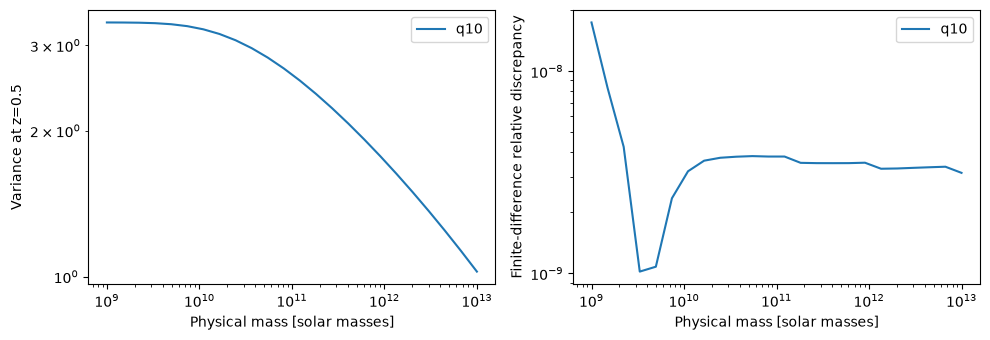

In [3]:
mass = np.geomspace(1e9, 1e13, 24)
step = 1e-4
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for q, model in models.items():
    upper, lower = mass*np.exp(step), mass*np.exp(-step)
    numerical = (model.sigmaMz(upper,.5)**2-model.sigmaMz(lower,.5)**2)/(upper-lower)
    analytic = model.dsdm(mass,.5)
    relative = np.abs(numerical/analytic-1)
    assert relative.max() < 4e-8
    axes[0].loglog(mass, model.sigmaMz(mass,.5)**2, label=f"q{q}")
    axes[1].loglog(mass, relative, label=f"q{q}")
    print(f"q{q}: maximum derivative relative discrepancy {relative.max():.3g}")
axes[0].set(xlabel="Physical mass [solar masses]",ylabel="Variance at z=0.5")
axes[1].set(xlabel="Physical mass [solar masses]",ylabel="Finite-difference relative discrepancy")
for ax in axes: ax.legend()
fig.tight_layout()
plt.show()

The portable high-resolution integral check and one-correction-at-a-time
results live in the family validation bundle. q5 and q10 have different power
suppression and abundance even when their convention-specific half-mode scales
coincide. q10 was adopted on 2026-09-11; q5 is retained only as historical
evidence and is not rerun through the product API. The user adopted survivor-based satellite counts; see `docs/surviving-observables.md` for thresholds and axes. The measured
resolution dependence and the approved default policy follow below.

## Fixed-grid redshift refinement

The user approved retaining the existing `dz=0.1` default on 2026-09-10.
This does not certify its accuracy. The frozen sweep fixes M0=1e12 Msun,
WDM mass=2 keV, zmax=7, N_ma=16, N_herm=3, N_hermNa=4 and accretion masses
from 1e5 to 1e10 Msun. The finest redshift grid is a finite comparator;
other settings are reduced and are not the complete default configuration.
See `docs/resolution-and-review.md` for full provenance and rerun commands.

q5 count_surviving: .1→.0125 4.9402%; last refinement 0.6856%
q5 bound_mass_fraction: .1→.0125 17.1989%; last refinement 2.2662%
q10 count_surviving: .1→.0125 4.9996%; last refinement 0.6994%
q10 bound_mass_fraction: .1→.0125 17.6631%; last refinement 2.3113%


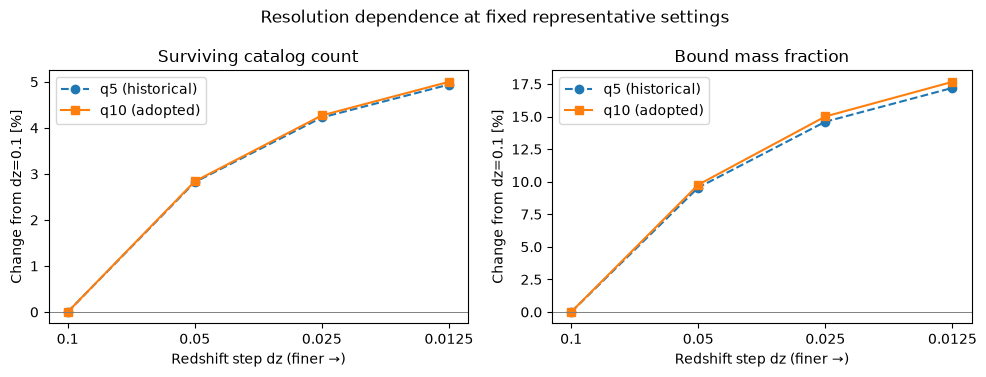

In [4]:
convergence_root = root / "validation" / "convergence"
convergence_provenance = json.loads((convergence_root / "provenance.json").read_text())
for filename, expected_hash in convergence_provenance["files"].items():
    assert hashlib.sha256((convergence_root / filename).read_bytes()).hexdigest() == expected_hash
redshift_results = json.loads((convergence_root / "redshift-convergence.json").read_text())
reconciliation = json.loads((convergence_root / "redshift-convergence-audit.json").read_text())
assert reconciliation["summary_sha256"] == convergence_provenance["files"]["redshift-convergence.json"]
assert len(reconciliation["checks"]) == 8
steps = np.array([.1, .05, .025, .0125])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for q in (5, 10):
    metrics = redshift_results["metrics"][f"q{q}"]
    for axis, field in zip(axes, ("count_surviving", "bound_mass_fraction")):
        values = np.array([metrics[str(step)][field] for step in steps])
        change = (values / values[0] - 1) * 100
        axis.semilogx(steps, change, "o--" if q == 5 else "s-", label="q5 (historical)" if q == 5 else "q10 (adopted)")
        print(f"q{q} {field}: .1→.0125 {change[-1]:.4f}%; last refinement {(values[-1]/values[-2]-1)*100:.4f}%")
for axis, title in zip(axes, ("Surviving catalog count", "Bound mass fraction")):
    axis.set(title=title, xlabel="Redshift step dz (finer →)", ylabel="Change from dz=0.1 [%]")
    axis.set_xticks(steps, ["0.1", "0.05", "0.025", "0.0125"])
    axis.minorticks_off()
    axis.invert_xaxis()
    axis.axhline(0, color="grey", linewidth=.7)
    axis.legend()
fig.suptitle("Resolution dependence at fixed representative settings")
fig.tight_layout()
plt.show()

The `.1→.0125` comparison changes counts by 4.940%/5.000% and mass
fractions by 17.199%/17.663% for q5/q10. The final halving still changes
mass fractions by about 2.3%; this is not a measured continuum error.
Independent mass/host-quadrature refinements and full reproduction instructions
are recorded in the review document. Refining the default step is outside the
agreed preparation scope. No claim of simulation calibration follows.